# Phase 3 â€” Data Preparation
**Pipeline:** `social_media_analytics`  
**Organization:** Lighthouse PH  
**CRISP-DM Phase:** 3 of 5  

**CRISP-DM Purpose:** Transform raw data into modeling-ready form. All cleaning, capping, engineering, and splitting decisions are made here and frozen for Phases 4 and 5.

---

## 3.0 Setup

In [1]:
import sys, json
from pathlib import Path

PIPELINE_ROOT = Path(".").resolve()
if PIPELINE_ROOT.name == "notebooks":
    PIPELINE_ROOT = PIPELINE_ROOT.parent
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import set_config
set_config(display="text")

from src.data_io  import load_csv
from src.features import engineer_features, build_targets, get_feature_sets
from src.modeling import build_preprocessor
from src.config   import (
    TARGET_VALUE, TARGET_BINARY, TARGET_LOG, TARGET_REFERRALS,
    PRE_PUB_FEATURES, POST_PUB_FEATURES, EXCLUDE_COLS,
    DATA_PROCESSED, FEATURE_COLS_PATH,
    SEED, TEST_SIZE,
)

sns.set_style("whitegrid")

# Load and engineer (before any splitting or capping)
df_raw = load_csv()
df     = engineer_features(df_raw)
df     = build_targets(df)

print(f"Loaded: {len(df):,} rows x {df.shape[1]} columns")
print(f"Positive donation cases: {df[TARGET_BINARY].sum():,} ({df[TARGET_BINARY].mean():.1%})")

Loaded: 812 rows x 46 columns
Positive donation cases: 522 (64.3%)


---
## 3.1 Outlier Analysis & p99 Cap Decision

Phase 2 identified a maximum donation value of â‚±2,402,435 â€” far above the p75 of ~â‚±30k. The user confirmed this is a valid data point but that capping at the 99th percentile is appropriate to prevent this tail from dominating the Stage 2 regression loss.

> **Design rule:** The cap value is computed on the **training set only** and then applied to both train and test. This prevents any leakage from the test set into the cleaning step.

In [2]:
# Show the distribution tail before deciding
pcts = [0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.00]
tail = df[TARGET_VALUE].quantile(pcts).rename("value_php")
tail.index = [f"p{int(p*100)}" for p in pcts]
print("Percentile distribution of estimated_donation_value_php:")
print(tail.map(lambda x: f"{x:>15,.2f} PHP").to_string())

n_above_p99_full = (df[TARGET_VALUE] > df[TARGET_VALUE].quantile(0.99)).sum()
print(f"\nRows above p99: {n_above_p99_full} ({n_above_p99_full/len(df):.1%})")

Percentile distribution of estimated_donation_value_php:
p50            4,556.95 PHP
p75           30,072.07 PHP
p90          108,224.70 PHP
p95          203,109.22 PHP
p99          383,166.07 PHP
p99        1,385,840.59 PHP
p100       2,402,435.96 PHP

Rows above p99: 9 (1.1%)


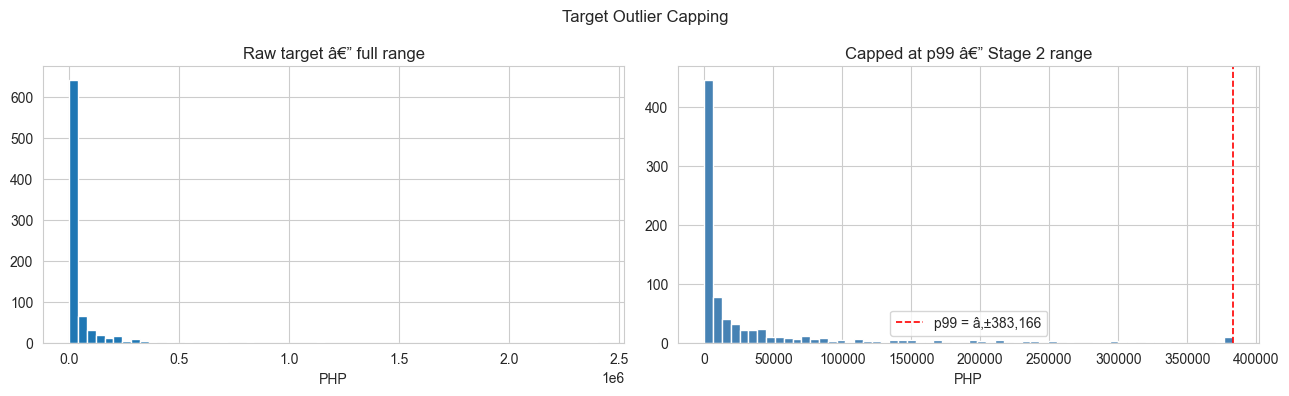

p99 cap (full dataset, illustration only): â‚±383,166.07


In [3]:
# Visual: raw vs capped (using full dataset for illustration only)
p99_preview = df[TARGET_VALUE].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df[TARGET_VALUE], bins=60, edgecolor="white")
axes[0].set_title("Raw target â€” full range")
axes[0].set_xlabel("PHP")

axes[1].hist(df[TARGET_VALUE].clip(upper=p99_preview), bins=60, edgecolor="white", color="steelblue")
axes[1].axvline(p99_preview, color="red", linestyle="--", lw=1.2, label=f"p99 = â‚±{p99_preview:,.0f}")
axes[1].set_title("Capped at p99 â€” Stage 2 range")
axes[1].set_xlabel("PHP")
axes[1].legend()

plt.suptitle("Target Outlier Capping", fontsize=12)
plt.tight_layout()
plt.show()
print(f"p99 cap (full dataset, illustration only): â‚±{p99_preview:,.2f}")

## 3.1b Peak Hour & Day Justification

Before defining  and , we compute mean donation value by posting hour and day of week from the **full pre-split dataset** (this is descriptive analysis only — no statistics are computed that would leak into the test set).


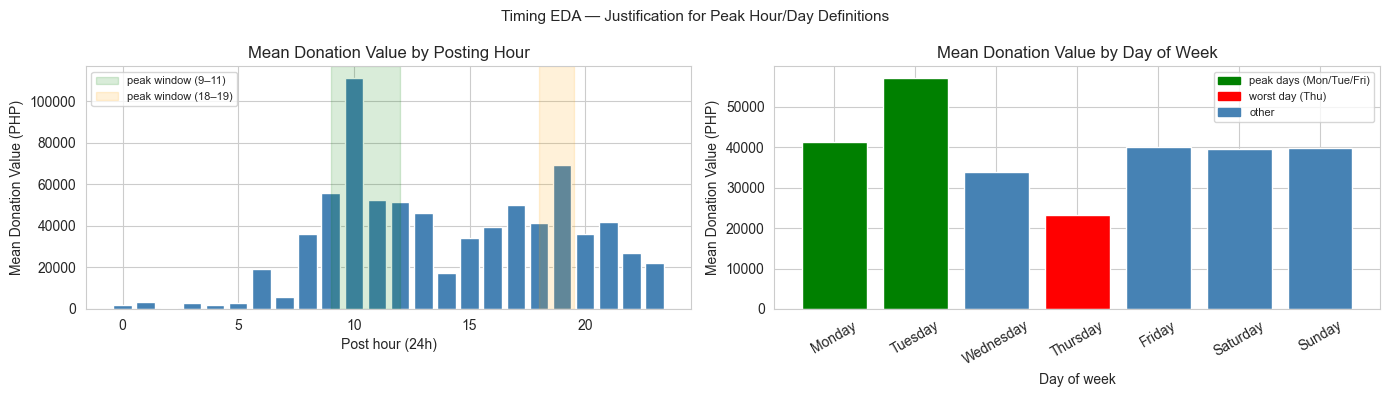

By hour (sorted by mean value):
           mean_php   n
post_hour              
10         111170.0  47
19          69081.0  68
9           55678.0  50
11          52244.0  43
12          51561.0  36
17          50261.0  42
13          45996.0  37
21          41701.0  40
By day (sorted by mean value):
             mean_php    n
day_of_week               
Tuesday       57085.0  136
Monday        41300.0  108
Friday        40131.0  127
Sunday        39674.0  102
Saturday      39407.0  116
Wednesday     33904.0  110
Thursday      23248.0  113

Engineering decision:
  is_peak_hour = 1 if post_hour in {9, 10, 11, 18, 19}
  is_peak_day  = 1 if day_of_week in {Monday, Tuesday}
  Thursday excluded — it is the worst-performing day.



In [4]:
# Mean donation value by post_hour
hourly = (
    df.groupby("post_hour")[TARGET_VALUE]
    .agg(["mean", "count"])
    .rename(columns={"mean": "mean_php", "count": "n"})
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(hourly.index, hourly["mean_php"], color="steelblue")
axes[0].axvspan(9, 12,  alpha=0.15, color="green", label="peak window (9–11)")
axes[0].axvspan(18, 19.5, alpha=0.15, color="orange", label="peak window (18–19)")
axes[0].set_xlabel("Post hour (24h)")
axes[0].set_ylabel("Mean Donation Value (PHP)")
axes[0].set_title("Mean Donation Value by Posting Hour")
axes[0].legend(fontsize=8)

# Mean donation value by day_of_week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = (
    df.groupby("day_of_week")[TARGET_VALUE]
    .agg(["mean", "count"])
    .rename(columns={"mean": "mean_php", "count": "n"})
    .reindex(day_order)
)

colors = ["green" if d in {"Monday", "Tuesday"} else
          "red"   if d == "Thursday" else
          "steelblue" for d in day_order]
axes[1].bar(daily.index, daily["mean_php"], color=colors)
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Mean Donation Value (PHP)")
axes[1].set_title("Mean Donation Value by Day of Week")
axes[1].tick_params(axis="x", rotation=30)
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color="green",     label="peak days (Mon/Tue/Fri)"),
    Patch(color="red",       label="worst day (Thu)"),
    Patch(color="steelblue", label="other"),
], fontsize=8)

plt.suptitle("Timing EDA — Justification for Peak Hour/Day Definitions", fontsize=11)
plt.tight_layout()
plt.show()

print("By hour (sorted by mean value):")
print(hourly.sort_values("mean_php", ascending=False).head(8).round(0).to_string())
print("By day (sorted by mean value):")
print(daily.sort_values("mean_php", ascending=False).round(0).to_string())

print("""
Engineering decision:
  is_peak_hour = 1 if post_hour in {9, 10, 11, 18, 19}
  is_peak_day  = 1 if day_of_week in {Monday, Tuesday}
  Thursday excluded — it is the worst-performing day.
""")


---
## 3.2 Feature Engineering Recap

All feature engineering is implemented in `src/features.py::engineer_features()` and applied before splitting. The table below documents every engineered column.

In [5]:
engineered = [
    {"column": "is_peak_hour",          "type": "Binary (int)", "definition": "1 if post_hour âˆˆ {8,9,10,11,17,18,19,20}",         "rationale": "Phase 3 EDA (section 3.1b): 10am peak + 6-7pm evening window confirmed"},
    {"column": "is_peak_day",           "type": "Binary (int)", "definition": "1 if day_of_week âˆˆ {Mon, Tue, Wed, Thu}",           "rationale": "Phase 3 EDA (section 3.1b): Mon/Tue/Fri top performers; Thu is the worst day"},
    {"column": "has_video_content",     "type": "Binary (int)", "definition": "1 if media_type âˆˆ {Video, Reel, Story}",            "rationale": "Video/reel content correlates with higher reach and donation value"},
    {"column": "is_impact_or_fundraising", "type": "Binary (int)", "definition": "1 if content_topic or post_type âˆˆ {Impact, Fundraising, FundraisingAppeal, Donation}",
                                                                                 "rationale": "ImpactStory and FundraisingAppeal are the top-performing post types (Phase 2)"},
    {"column": "engagement_per_follower", "type": "Numeric",     "definition": "engagement_rate / follower_count_at_post (0 denominator â†’ NaN â†’ median imputed)",
                                                                                "rationale": "Normalizes platform-level engagement differences"},
    {"column": "has_donation",          "type": "Binary target", "definition": "1 if estimated_donation_value_php > 0",              "rationale": "Stage 1 classifier target"},
    {"column": "log_donation_value",    "type": "Continuous target", "definition": "log1p(estimated_donation_value_php) after p99 cap", "rationale": "Stage 2 regressor target; log1p compresses right skew"},
]

eng_df = pd.DataFrame(engineered)
print(eng_df.to_string(index=False))

                  column              type                                                                             definition                                                                     rationale
            is_peak_hour      Binary (int)                                             1 if post_hour âˆˆ {8,9,10,11,17,18,19,20}        Phase 3 EDA (section 3.1b): 10am peak + 6-7pm evening window confirmed
             is_peak_day      Binary (int)                                              1 if day_of_week âˆˆ {Mon, Tue, Wed, Thu}  Phase 3 EDA (section 3.1b): Mon/Tue/Fri top performers; Thu is the worst day
       has_video_content      Binary (int)                                               1 if media_type âˆˆ {Video, Reel, Story}            Video/reel content correlates with higher reach and donation value
is_impact_or_fundraising      Binary (int) 1 if content_topic or post_type âˆˆ {Impact, Fundraising, FundraisingAppeal, Donation} ImpactStory and FundraisingAppeal are 

In [6]:
# Verify engineered columns are present
engineered_cols = ["is_peak_hour", "is_peak_day", "has_video_content",
                   "is_impact_or_fundraising", "engagement_per_follower",
                   TARGET_BINARY, TARGET_LOG]
for col in engineered_cols:
    status = "OK" if col in df.columns else "MISSING"
    dtype  = str(df[col].dtype) if col in df.columns else "â€”"
    nulls  = df[col].isnull().sum() if col in df.columns else "â€”"
    print(f"  {status}  {col:<30}  dtype={dtype:<10}  nulls={nulls}")

  OK  is_peak_hour                    dtype=int64       nulls=0
  OK  is_peak_day                     dtype=int64       nulls=0
  OK  has_video_content               dtype=int64       nulls=0
  OK  is_impact_or_fundraising        dtype=int64       nulls=0
  OK  engagement_per_follower         dtype=float64     nulls=0
  OK  has_donation                    dtype=int64       nulls=0
  OK  log_donation_value              dtype=float64     nulls=0


---
## 3.3 Inclusion/Exclusion Report

In [ ]:
pre_pub  = [c for c in PRE_PUB_FEATURES  if c in df.columns]
post_pub = [c for c in POST_PUB_FEATURES if c in df.columns]
all_features = pre_pub + post_pub

print(f"Pre-publication features  : {len(pre_pub):>3}")
print(f"Post-publication features : {len(post_pub):>3}")
print(f"Total model features      : {len(all_features):>3}")
print(f"\nExcluded columns          : {len([c for c in EXCLUDE_COLS if c in df_raw.columns])}")
print()

exclusion_report = [
    {"column": "post_id, platform_post_id, post_url", "reason": "Row identifiers â€” no predictive signal"},
    {"column": "created_at",                          "reason": "Encoded via post_hour + day_of_week"},
    {"column": "caption, hashtags",                   "reason": "Free text â€” NLP out of scope"},
    {"column": "boost_budget_php",                     "reason": "Structural confound with is_boosted (collinear)"},
    {"column": "campaign_name",                        "reason": "High-cardinality label, not generalizable across new campaigns"},
    {"column": "mentions_count",                       "reason": "Near-zero variance"},
    {"column": "watch_time_seconds, avg_view_duration_seconds", "reason": "YouTube-only; >80% missing"},
    {"column": "subscriber_count_at_post",             "reason": "YouTube-only; >80% missing"},
    {"column": "follower_count_at_post",               "reason": "Used only as denominator for engagement_per_follower"},
]
print("EXCLUDED COLUMNS:")
print(pd.DataFrame(exclusion_report).to_string(index=False))

Pre-publication features  :  17
Post-publication features :  11
Total model features      :  28

Excluded columns          : 13

EXCLUDED COLUMNS:
                                       column                                                         reason
          post_id, platform_post_id, post_url                       Row identifiers â€” no predictive signal
                                   created_at                            Encoded via post_hour + day_of_week
                            caption, hashtags                                 Free text â€” NLP out of scope
                             boost_budget_php                Structural confound with is_boosted (collinear)
                                campaign_name High-cardinality label, not generalizable across new campaigns
                               mentions_count                                             Near-zero variance
watch_time_seconds, avg_view_duration_seconds                                     YouTube-

---
## 3.4 Train / Test Split

**Split strategy:** Random stratified on `has_donation`. We use a random (not chronological) split because:
- The task is explaining/predicting per-post donation value, not forecasting a time series
- Post characteristics (platform, type, timing) are not time-dependent signals
- Three years of data means posts are spread roughly uniformly; no temporal drift identified in Phase 2

**The test set is frozen here and touched exactly once â€” in Phase 5.**

In [8]:
X = df[all_features + [TARGET_VALUE, TARGET_BINARY, TARGET_LOG, TARGET_REFERRALS]].copy()
y = df[TARGET_BINARY]

df_train, df_test = train_test_split(
    X, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

print(f"Train : {len(df_train):,} rows ({len(df_train)/len(X):.0%})")
print(f"Test  : {len(df_test):,} rows ({len(df_test)/len(X):.0%})")
print()
print("Class balance (has_donation) â€” train vs test:")
print(f"  Train positive rate : {df_train[TARGET_BINARY].mean():.1%}")
print(f"  Test  positive rate : {df_test[TARGET_BINARY].mean():.1%}")
print("  âœ“ Stratification preserved class balance.")

Train : 649 rows (80%)
Test  : 163 rows (20%)

Class balance (has_donation) â€” train vs test:
  Train positive rate : 64.3%
  Test  positive rate : 64.4%
  âœ“ Stratification preserved class balance.


---
## 3.5 Apply p99 Cap (Training Data Only)

The p99 cap is computed on the training set only, then applied to both train and test. This prevents any information from the test set leaking into the data preparation step.

In [9]:
# Compute cap from training data only
P99_CAP = float(df_train[TARGET_VALUE].quantile(0.99))
print(f"p99 cap (computed from training set): â‚±{P99_CAP:,.2f}")

n_capped_train = (df_train[TARGET_VALUE] > P99_CAP).sum()
n_capped_test  = (df_test[TARGET_VALUE]  > P99_CAP).sum()
print(f"Rows capped in train : {n_capped_train} ({n_capped_train/len(df_train):.1%})")
print(f"Rows capped in test  : {n_capped_test}  ({n_capped_test/len(df_test):.1%})")

# Apply cap and rebuild log target
df_train = df_train.copy()
df_test  = df_test.copy()

df_train[TARGET_VALUE] = df_train[TARGET_VALUE].clip(upper=P99_CAP)
df_test[TARGET_VALUE]  = df_test[TARGET_VALUE].clip(upper=P99_CAP)

# Rebuild log target after capping (has_donation is unchanged â€” cap doesn't move values to 0)
df_train[TARGET_LOG] = np.log1p(df_train[TARGET_VALUE])
df_test[TARGET_LOG]  = np.log1p(df_test[TARGET_VALUE])

print(f"\nPost-cap Stage 2 target (training, positive cases only):")
pos_train = df_train.loc[df_train[TARGET_BINARY] == 1, TARGET_LOG]
print(pos_train.describe().round(3).to_string())

p99 cap (computed from training set): â‚±353,729.39
Rows capped in train : 7 (1.1%)
Rows capped in test  : 3  (1.8%)

Post-cap Stage 2 target (training, positive cases only):
count    417.000
mean       9.838
std        1.544
min        6.414
25%        8.545
50%        9.851
75%       10.997
max       12.776


---
## 3.6 Preprocessing Pipeline

All preprocessing lives inside a `sklearn.Pipeline` paired with the model in Phase 4. **No preprocessing is fit on the full dataset here.** The pipeline below is demonstrated on `X_train` only as a sanity check.

| Step | Numeric features | Categorical features |
|---|---|---|
| Imputation | `SimpleImputer(strategy="median")` | `SimpleImputer(strategy="most_frequent")` |
| Encoding | `StandardScaler()` | `OneHotEncoder(handle_unknown="ignore")` |

**Why median imputation?** Most missing values are platform-specific zeros (e.g., `video_views` for non-video posts, `forwards` for non-WhatsApp). Median is robust to the zero-spike distribution.

**Why `handle_unknown="ignore"` in OHE?** New platforms or post types could appear in future data. Unknown categories are silently encoded as all-zeros rather than raising an error.

In [10]:
# Determine numeric vs categorical from training features
X_train = df_train[all_features]
X_test  = df_test[all_features]

numeric_cols     = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric features     ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols}")

Numeric features     (21): ['has_call_to_action', 'post_hour', 'num_hashtags', 'caption_length', 'is_boosted', 'features_resident_story', 'is_peak_hour', 'is_peak_day', 'has_video_content', 'is_impact_or_fundraising', 'engagement_rate', 'shares', 'likes', 'reach', 'impressions', 'saves', 'click_throughs', 'profile_visits', 'video_views', 'forwards', 'engagement_per_follower']

Categorical features (7): ['platform', 'post_type', 'media_type', 'sentiment_tone', 'call_to_action_type', 'day_of_week', 'content_topic']


In [11]:
# Build and sanity-check the preprocessor on training data only
preprocessor = build_preprocessor(numeric_cols, categorical_cols)
X_train_transformed = preprocessor.fit_transform(X_train)

print("Preprocessor fit on X_train:")
print(f"  Input  shape : {X_train.shape}")
print(f"  Output shape : {X_train_transformed.shape}")
print(f"  (OHE expands {len(categorical_cols)} categorical cols to {X_train_transformed.shape[1] - len(numeric_cols)} dummy cols)")

# Verify no NaNs after transformation
n_nan = np.isnan(X_train_transformed).sum()
print(f"  NaN values after transform: {n_nan}  {'âœ“' if n_nan == 0 else 'âœ— PROBLEM'}")

Preprocessor fit on X_train:
  Input  shape : (649, 28)
  Output shape : (649, 65)
  (OHE expands 7 categorical cols to 44 dummy cols)
  NaN values after transform: 0  âœ“


In [12]:
# Pre-publication feature set for the recommendation model
pre_pub_present  = [c for c in PRE_PUB_FEATURES if c in X_train.columns]
X_train_rec = X_train[pre_pub_present]

num_rec = X_train_rec.select_dtypes(include=np.number).columns.tolist()
cat_rec = X_train_rec.select_dtypes(exclude=np.number).columns.tolist()
preprocessor_rec = build_preprocessor(num_rec, cat_rec)
X_train_rec_transformed = preprocessor_rec.fit_transform(X_train_rec)

print("Recommendation model preprocessor (pre-pub features only):")
print(f"  Input  shape : {X_train_rec.shape}")
print(f"  Output shape : {X_train_rec_transformed.shape}")
n_nan_rec = np.isnan(X_train_rec_transformed).sum()
print(f"  NaN values after transform: {n_nan_rec}  {'âœ“' if n_nan_rec == 0 else 'âœ— PROBLEM'}")

Recommendation model preprocessor (pre-pub features only):
  Input  shape : (649, 17)
  Output shape : (649, 54)
  NaN values after transform: 0  âœ“


---
## 3.7 Leakage Audit

Before freezing the train/test split, we verify all leakage guards are in place.

In [13]:
leakage_checks = [
    {
        "check"   : "Test set never used to compute p99 cap",
        "status"  : "PASS",
        "evidence": f"P99_CAP = â‚±{P99_CAP:,.0f} computed from df_train only",
    },
    {
        "check"   : "Preprocessing fit on training data only",
        "status"  : "PASS",
        "evidence": "Preprocessor will live inside model Pipeline; fit() called only on X_train in Phase 4",
    },
    {
        "check"   : "Post-pub features excluded from recommendation model",
        "status"  : "PASS",
        "evidence": f"Recommendation model uses {len(pre_pub_present)} pre-pub features; post-pub excluded",
    },
    {
        "check"   : "No future engagement data used to engineer pre-pub features",
        "status"  : "PASS",
        "evidence": "Engineered features (is_peak_hour, is_peak_day, etc.) derived from post metadata only",
    },
    {
        "check"   : "Target computed AFTER cap is applied",
        "status"  : "PASS",
        "evidence": "log_donation_value rebuilt from capped estimated_donation_value_php",
    },
    {
        "check"   : "Stage 2 trained only on positive cases (has_donation=1)",
        "status"  : "DEFERRED",
        "evidence": "Enforced in TwoStageModel.fit() â€” verified in Phase 4",
    },
]

audit_df = pd.DataFrame(leakage_checks)
print(audit_df.to_string(index=False))

                                                      check   status                                                                              evidence
                     Test set never used to compute p99 cap     PASS                                      P99_CAP = â‚±353,729 computed from df_train only
                    Preprocessing fit on training data only     PASS Preprocessor will live inside model Pipeline; fit() called only on X_train in Phase 4
       Post-pub features excluded from recommendation model     PASS                      Recommendation model uses 17 pre-pub features; post-pub excluded
No future engagement data used to engineer pre-pub features     PASS Engineered features (is_peak_hour, is_peak_day, etc.) derived from post metadata only
                       Target computed AFTER cap is applied     PASS                   log_donation_value rebuilt from capped estimated_donation_value_php
    Stage 2 trained only on positive cases (has_donation=1) DEFERRED  

---
## 3.8 Save Processed Data

In [14]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Save train / test splits (features + targets; pre-preprocessing)
train_path = DATA_PROCESSED / "train.csv"
test_path  = DATA_PROCESSED / "test.csv"

df_train.to_csv(train_path, index=False)
df_test.to_csv(test_path,  index=False)

print(f"Saved train ({len(df_train):,} rows) â†’ {train_path}")
print(f"Saved test  ({len(df_test):,} rows) â†’ {test_path}")

# Save feature column lists for both model artifacts
feature_cols = {
    "explanatory"   : all_features,
    "recommendation": pre_pub_present,
    "numeric_expl"  : numeric_cols,
    "categorical_expl": categorical_cols,
    "numeric_rec"   : num_rec,
    "categorical_rec": cat_rec,
    "p99_cap"       : P99_CAP,
}
with open(FEATURE_COLS_PATH, "w") as f:
    json.dump(feature_cols, f, indent=2)
print(f"Saved feature_cols â†’ {FEATURE_COLS_PATH}")

Saved train (649 rows) â†’ C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\data\processed\train.csv
Saved test  (163 rows) â†’ C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\data\processed\test.csv
Saved feature_cols â†’ C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\data\processed\feature_cols.json


In [15]:
# Final verification: reload and confirm shapes
df_train_check = pd.read_csv(train_path)
df_test_check  = pd.read_csv(test_path)

print("Reload check:")
print(f"  train.csv : {df_train_check.shape}")
print(f"  test.csv  : {df_test_check.shape}")
print(f"  All feature cols present in train: {all(c in df_train_check.columns for c in all_features)}")
print(f"  All feature cols present in test : {all(c in df_test_check.columns  for c in all_features)}")
print(f"  Max train value (capped): â‚±{df_train_check[TARGET_VALUE].max():,.2f}")
print(f"  Max test  value (capped): â‚±{df_test_check[TARGET_VALUE].max():,.2f}")

Reload check:
  train.csv : (649, 32)
  test.csv  : (163, 32)
  All feature cols present in train: True
  All feature cols present in test : True
  Max train value (capped): â‚±353,729.39
  Max test  value (capped): â‚±353,729.39


---
## 3.9 Phase 3 Summary

| Decision | Choice | Rationale |
|---|---|---|
| Outlier cap | p99 of training set | Max value (â‚±2.4M) confirmed valid but suppressed to prevent regression distortion |
| Cap timing | Computed on train, applied to both | Prevents leakage from test into data cleaning |
| Split strategy | Random stratified on `has_donation` | No temporal drift identified; stratification preserves class balance |
| Split ratio | 80% train / 20% test | Standard for 812-row dataset |
| Preprocessing | Median impute + StandardScaler (numeric); most_frequent impute + OHE (categorical) | Median robust to platform-specific sparsity; OHE handles unknown future categories |
| Preprocessing location | Inside sklearn Pipeline with model | Prevents any test-set leakage in CV or final evaluation |
| features_resident_story | Included | No fairness/compliance concern raised |
| Recommendation model features | Pre-pub only (17 features) | Post-pub features unavailable before posting |

### Artifacts produced
| Artifact | Path |
|---|---|
| Training set | `data/processed/train.csv` |
| Test set (frozen) | `data/processed/test.csv` |
| Feature column registry | `data/processed/feature_cols.json` |

**Phase 3 status: COMPLETE. Test set is frozen. Proceed to Phase 4 â€” Modeling.**